In [100]:
!pip install vaderSentiment
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
import nltk
nltk.download('stopwords')
nltk.download('wordnet')
from nltk.stem import WordNetLemmatizer

[nltk_data] Downloading package stopwords to /Users/juliana-
[nltk_data]     figueroa/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /Users/juliana-
[nltk_data]     figueroa/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


In [101]:
#Load Data
airbnb = pd.read_csv("tripadvisor_hotel_reviews.csv")

In [102]:
airbnb.head()

,Review,Rating
0,nice hotel expensive parking got good deal sta...,4
1,ok nothing special charge diamond member hilto...,2
2,nice rooms not 4* experience hotel monaco seat...,3
3,"unique, great stay, wonderful time hotel monac...",5
4,"great stay great stay, went seahawk game aweso...",5


In [103]:
print(airbnb.shape)

(20491, 2)


In [104]:
print(airbnb.isnull())

       Review  Rating
0       False   False
1       False   False
2       False   False
3       False   False
4       False   False
...       ...     ...
20486   False   False
20487   False   False
20488   False   False
20489   False   False
20490   False   False

[20491 rows x 2 columns]


In [105]:
print("Missing Values:")
print(airbnb.isnull().sum())

Missing Values:
Review    0
Rating    0
dtype: int64


In [106]:
print("There are no missing values in this dataset!")

There are no missing values in this dataset!


In [107]:
airbnb.describe()

,Rating
count,20491.000000
mean,3.952223
std,1.233030
min,1.000000
25%,3.000000
50%,4.000000
75%,5.000000
max,5.000000


In [108]:
airbnb['Rating'].value_counts().sort_index(ascending=True)

Rating
1    1421
2    1793
3    2184
4    6039
5    9054
Name: count, dtype: int64

In [109]:
airbnb.loc[airbnb['Review'] == ""]

,Review,Rating


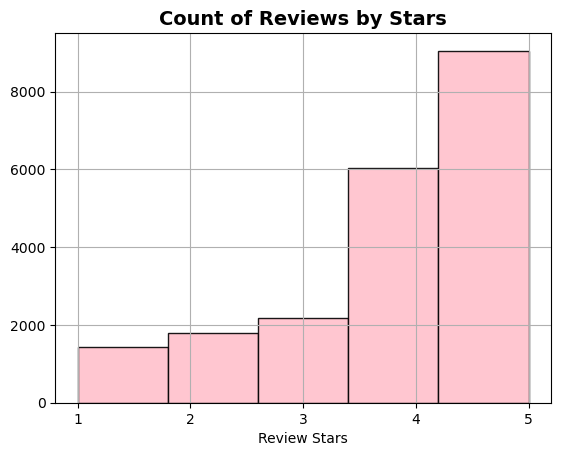

In [110]:
airbnb['Rating'].hist(bins=5, alpha=0.90, color='pink', edgecolor='black')
plt.title("Count of Reviews by Stars", fontsize=14, fontweight='bold')
plt.xlabel("Review Stars")
plt.xticks([1, 2, 3, 4, 5])
plt.show()

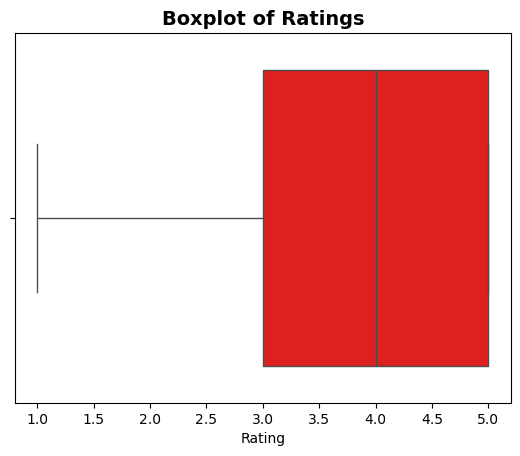

In [111]:
sns.boxplot(x=airbnb['Rating'], color='red')
plt.title("Boxplot of Ratings",fontsize=14, fontweight='bold')
plt.show()

In [112]:
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
import re

stopwords_list = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def clean_text_final(text):
    text = str(text).lower() #Converts text to lowercase

    text = re.sub(r'<.*?>', '', text) #Removes HTML tags
    text = re.sub(r'http\S+|www\S+', '', text) #Removes URLs
    text = re.sub(r'@\w+|#', '', text) #Removes mentions and hashtags
    text = re.sub(r'[^a-zA-Z\s]', '', text) #Removes punctuation, special characters, and numbers

    words = text.split() #Tokenize into individual words

    words = [lemmatizer.lemmatize(word) for word in words 
             if word not in stopwords_list and len(word) > 2]

    return " ".join(words)
    

In [113]:
airbnb['clean_text_final'] = airbnb['Review'].apply(clean_text_final)
airbnb.head(10)

,Review,Rating,clean_text_final
0,nice hotel expensive parking got good deal sta...,4,nice hotel expensive parking got good deal sta...
1,ok nothing special charge diamond member hilto...,2,nothing special charge diamond member hilton d...
2,nice rooms not 4* experience hotel monaco seat...,3,nice room experience hotel monaco seattle good...
3,"unique, great stay, wonderful time hotel monac...",5,unique great stay wonderful time hotel monaco ...
4,"great stay great stay, went seahawk game aweso...",5,great stay great stay went seahawk game awesom...
5,love monaco staff husband stayed hotel crazy w...,5,love monaco staff husband stayed hotel crazy w...
6,"cozy stay rainy city, husband spent 7 nights m...",5,cozy stay rainy city husband spent night monac...
7,"excellent staff, housekeeping quality hotel ch...",4,excellent staff housekeeping quality hotel cho...
8,"hotel stayed hotel monaco cruise, rooms genero...",5,hotel stayed hotel monaco cruise room generous...
9,excellent stayed hotel monaco past w/e delight...,5,excellent stayed hotel monaco past delight rec...


In [114]:
print(list(stopwords_list)[:10]) #Example of words, the model will remove from text

['hasn', "i'm", 'no', "that'll", 'very', 'theirs', "they'd", 'there', 'if', 'why']


In [122]:
# Applies VADER (sentiment analysis tool) to classify text as positive, negative or neutral
analyzer = SentimentIntensityAnalyzer()

def map_sentiment(text):
    score = analyzer.polarity_scores(text)['compound']
    
    if score <= -0.05:
        return 0 # Negative
    elif score >= 0.05:
        return 2 # Positive
    else:
        return 1 # Neutral

airbnb['sentiment'] = airbnb['clean_text_final'].apply(map_sentiment)

airbnb.head()

,Review,Rating,clean_text_final,sentiment
0,nice hotel expensive parking got good deal sta...,4,nice hotel expensive parking got good deal sta...,2
1,ok nothing special charge diamond member hilto...,2,nothing special charge diamond member hilton d...,2
2,nice rooms not 4* experience hotel monaco seat...,3,nice room experience hotel monaco seattle good...,2
3,"unique, great stay, wonderful time hotel monac...",5,unique great stay wonderful time hotel monaco ...,2
4,"great stay great stay, went seahawk game aweso...",5,great stay great stay went seahawk game awesom...,2


In [130]:
pd.crosstab(airbnb['Rating'], airbnb['sentiment'])

sentiment,0,1,2
Rating,,,
1,660,25,736
2,297,23,1473
3,78,11,2095
4,27,3,6009
5,18,6,9030


In [123]:
!pip install wordcloud

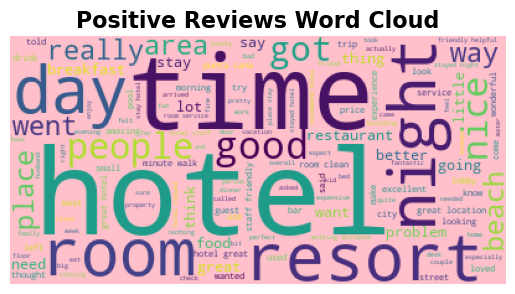

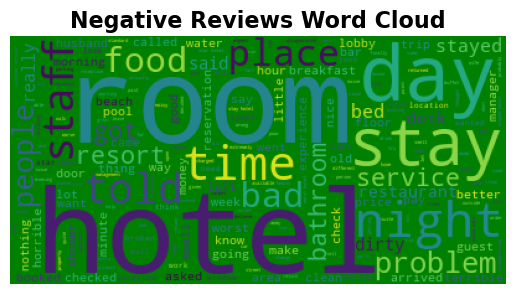

In [124]:
from wordcloud import WordCloud

positive_reviews = airbnb[airbnb['sentiment']== 2]['clean_text_final']
negative_reviews = airbnb[airbnb['sentiment']== 0]['clean_text_final']


positive_text = " ".join(positive_reviews)
negative_text = " ".join(negative_reviews)

# Create word clouds
wc_pos = WordCloud(background_color='pink').generate(positive_text)
wc_neg = WordCloud(background_color='green').generate(negative_text)

plt.imshow(wc_pos)
plt.title("Positive Reviews Word Cloud",fontsize=16, fontweight='bold')
plt.axis('off')
plt.show()

plt.imshow(wc_neg)
plt.title("Negative Reviews Word Cloud", fontsize=16, fontweight='bold')
plt.axis('off')
plt.show()

    Word  Count
0  hotel  52956
1   room  46378
2  great  21098
3   good  17054
4  staff  16280
5   stay  15341
6  night  14085
7    day  12961
8   time  12611
9   nice  12412


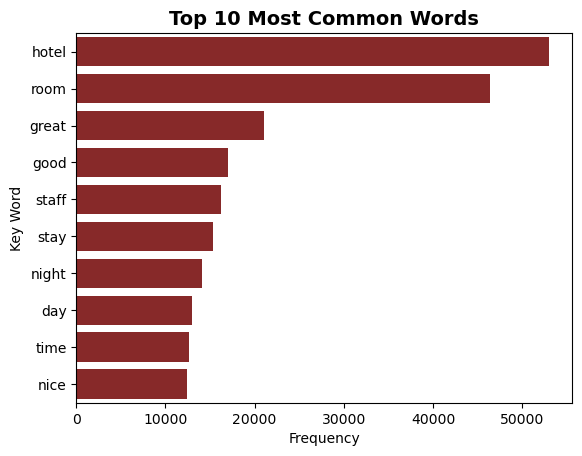

In [125]:
from collections import Counter

words = " ".join(airbnb['clean_text_final']).split()
common_words = Counter(words).most_common(10)

words_df = pd.DataFrame(common_words, columns=['Word', 'Count'])
print(words_df)

sns.barplot(x='Count', y='Word', data=words_df, color='darkred', alpha=0.9)
plt.title("Top 10 Most Common Words", fontsize=14, fontweight='bold')
plt.ylabel("Key Word")
plt.xlabel("Frequency")
plt.show()

In [127]:
airbnb.head(10)

,Review,Rating,clean_text_final,sentiment
0,nice hotel expensive parking got good deal sta...,4,nice hotel expensive parking got good deal sta...,2
1,ok nothing special charge diamond member hilto...,2,nothing special charge diamond member hilton d...,2
2,nice rooms not 4* experience hotel monaco seat...,3,nice room experience hotel monaco seattle good...,2
3,"unique, great stay, wonderful time hotel monac...",5,unique great stay wonderful time hotel monaco ...,2
4,"great stay great stay, went seahawk game aweso...",5,great stay great stay went seahawk game awesom...,2
5,love monaco staff husband stayed hotel crazy w...,5,love monaco staff husband stayed hotel crazy w...,2
6,"cozy stay rainy city, husband spent 7 nights m...",5,cozy stay rainy city husband spent night monac...,2
7,"excellent staff, housekeeping quality hotel ch...",4,excellent staff housekeeping quality hotel cho...,2
8,"hotel stayed hotel monaco cruise, rooms genero...",5,hotel stayed hotel monaco cruise room generous...,2
9,excellent stayed hotel monaco past w/e delight...,5,excellent stayed hotel monaco past delight rec...,2


In [131]:
#Separate features (X) and target (y)

X = airbnb['clean_text_final'] #Text that needs to be converted to numbers for modeling
y = airbnb['sentiment'] #Already numbers

print("\nFeatures:\n", X.head())
print("\nPrediction:\n", y.head())


Features:
 0    nice hotel expensive parking got good deal sta...
1    nothing special charge diamond member hilton d...
2    nice room experience hotel monaco seattle good...
3    unique great stay wonderful time hotel monaco ...
4    great stay great stay went seahawk game awesom...
Name: clean_text_final, dtype: object

Prediction:
 0    2
1    2
2    2
3    2
4    2
Name: sentiment, dtype: int64


Split data into training, validation, and test sets to ensure proper model evaluation. This helps prevent bias and ensures that each subset is representative of the overall data. The validation set is used for model tuning, while the test set is reserved for final performance evaluation.

In [137]:
from sklearn.model_selection import train_test_split
print("Splitting data into training (70%) and testing(30%)")
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=42, stratify=y)

print("Splitting testing set (30%) in two: Validation and Testing set")
X_val, X_test, y_val, y_test = train_test_split(X_test, y_test, test_size=0.50, random_state=42, stratify=y_test)

Splitting data into training (70%) and testing(30%)
Splitting testing set (30%) in two: Validation and Testing set


In [140]:
# Converts text reviews into numerical features
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(max_features=5000)

X_train_vec = vectorizer.fit_transform(X_train)
X_val_vec = vectorizer.transform(X_val)
X_test_vec = vectorizer.transform(X_test)

In [143]:
# Training Naive Bayes model
from sklearn.naive_bayes import MultinomialNB

nb_model = MultinomialNB()
nb_model.fit(X_train_vec, y_train)

# Validate predictions
y_val_pred = nb_model.predict(X_val_vec)

# Make predictions
y_test_pred = nb_model.predict(X_test_vec)

In [146]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

print("Accuracy:", accuracy_score(y_test, y_test_pred))
print("Precision:", precision_score(y_test, y_test_pred, average='weighted', zero_division=0))
print("Recall:", recall_score(y_test, y_test_pred, average='weighted'))
print("F1-Score:", f1_score(y_test, y_test_pred, average='weighted'))

print("\nDetailed Report:\n")
print(classification_report(y_test, y_test_pred, zero_division=0))

Accuracy: 0.9456733897202342
Precision: 0.9453764882438251
Recall: 0.9456733897202342
F1-Score: 0.9207989491743765

Detailed Report:

              precision    recall  f1-score   support

           0       1.00      0.03      0.06       162
           1       0.00      0.00      0.00        10
           2       0.95      1.00      0.97      2902

    accuracy                           0.95      3074
   macro avg       0.65      0.34      0.34      3074
weighted avg       0.95      0.95      0.92      3074



Important Insights and Business Recommendations

The sentiment distribution across hotel reviews shows a strong skew toward positive feedback. Based on the VADER sentiment classification, the majority of reviews were labeled as positive, which aligns with the overall rating distribution where most users gave 4 or 5 stars. However, the cross-tabulation between ratings and sentiment revealed some inconsistencies. For example, a noticeable number of low-rated reviews (1–2 stars) were still classified as positive. This suggests that users may leave relatively neutral or mildly positive written feedback even when assigning a low rating, highlighting a limitation of text-based sentiment analysis.

When analyzing the most common words and word clouds, several key patterns emerged. The most frequently used words in positive reviews were “great,” “good,” “nice,” “staff,” and “location,” indicating that customer satisfaction is strongly tied to service quality and convenience. On the other hand, negative reviews often contained words like “dirty,” “problem,” “bad,” “old,” and “told,” suggesting recurring issues related to cleanliness, maintenance, and unmet expectations. Interestingly, words like “hotel,” “room,” and “stay” appeared in both positive and negative contexts, suggesting a split sentiment with these and that the same core experience can vary significantly depending on execution.

From a business perspective, these insights provide clear areas for improvement. First, cleanliness and room condition should be top priorities, as they consistently appear in the negative sentiment category. Regular maintenance and quality control checks could significantly reduce complaints. Second, improving communication and customer service can address issues reflected in words like “told” and “problem,” which may indicate frustration with staff interactions. Lastly, reinforcing strengths such as location and staff friendliness can help maintain high levels of positive sentiment.

In the end, while sentiment analysis provides valuable insights into customer feedback, it should be used alongside rating data for a more complete understanding. Combining both allows businesses to better identify gaps between customer expectations and their actual experiences.